In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os

# check out the data

In [16]:
!ls data/

current_foreground_noise_model.dat  foreground_noise_model.dat
current_instrument_noise_model.dat  full_noise_model.dat
current_sgwb_noise_model.dat        instrument_noise_model.dat
dft_data.dat                        power_data.dat
dwt_data.dat                        power_noise_reconstruction.dat
final_foreground_noise_model.dat    scaleogram_data.dat
final_full_noise_model.dat          sgwb_noise_model.dat
final_instrument_noise_model.dat    whitened_data.dat
final_sgwb_noise_model.dat


In [161]:
scaleogram_data = np.loadtxt('data/scaleogram_data.dat')
full_noise = np.loadtxt('data/full_noise_model.dat')

In [162]:
# cols are t, f, |X|^2, |Y|^2, |Z|^2

In [163]:
scaleogram_data.shape

(16200, 5)

In [164]:
# cols are t, f, CXX, CYY, CZZ, CXY, CXZ, CYZ

In [165]:
full_noise.shape

(16200, 8)

In [166]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from matplotlib import colors
%matplotlib inline
def wavelet_specgram(t, f, pz, Nt = 512, lognorm=False):
    Nf = t.shape[0] // Nt
    if t.shape[0] != Nt*Nf or f.shape[0] != Nt*Nf:
        print("Nt or Nf is wrong")
    cmap = 'bwr'
    z = pz.copy()
    if lognorm:
        z = np.ma.masked_less_equal(z.astype(float), 0)
        norm = colors.LogNorm(vmin=z.min(), vmax = z.max())
    else:
        norm = colors.Normalize(vmin=z.min(), vmax = z.max())
    #plt.imshow(z.reshape((Nf,Nt)),cmap=cmap,norm=norm,aspect=9/16*Nt/Nf,interpolation='none')
    fig, ax = plt.subplots()
    m = ax.pcolormesh(t[::Nf], f[:Nf], z.reshape((Nt,Nf)).T, cmap=cmap, norm=norm, shading='auto',snap=True, rasterized=True)
    fig.colorbar(m,ax=ax)
    plt.xlabel('t')
    plt.ylabel('f')
    plt.show()
    

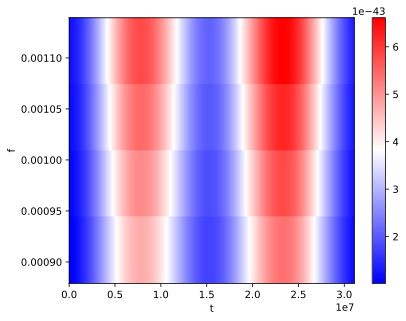

In [167]:
wavelet_specgram(full_noise[:,0], full_noise[:,1], full_noise[:,2], Nt=4050)

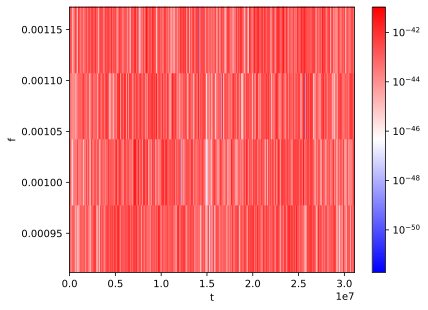

In [168]:
wavelet_specgram(scaleogram_data[:,0], scaleogram_data[:,1], scaleogram_data[:,2], Nt=4050, lognorm=True)

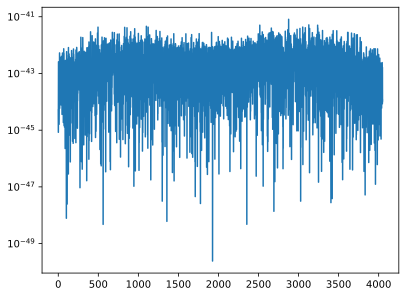

In [169]:
plt.semilogy(scaleogram_data[::4,4])

# check out the chains

In [170]:
sgwb = np.loadtxt('chains/sgwb_chain.dat')#, max_rows=700)

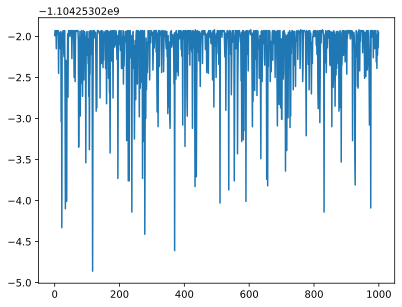

In [171]:
plt.plot(sgwb[:,1])

In [172]:
from corner import corner

In [173]:
sgwb_chain = np.array(
    [
        sgwb[:,2], # logA
        sgwb[:,3], # alpha
    ]).T
sgwb_labels = [r'$\log A$', r'$\alpha$']

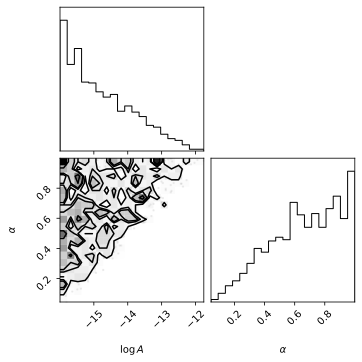

In [174]:
corner(sgwb_chain, labels = sgwb_labels)
plt.show()